# D2D Logs — Exploratory Data Analysis

This notebook is a **first-contact** exploration of `data/logs.parquet`. The goal is to
understand the dataset the way an analyst would on day one: *what columns exist, how are they
distributed, what relates to what, and where are the data-quality landmines* — **without
assuming any particular modeling target up front**.

We treat the file as a generic interaction log: each row is one decision a rep made at one
address, plus whatever was observed afterward. By the end we'll have formed a hypothesis about
which columns are *context*, which are *actions*, and which look like *outcomes/response* —
which is exactly the framing a reward model would need.

> Note: this notebook deliberately rediscovers structure from the raw frame. It does not import
> the project's feature/oracle code, so it stays an honest, target-agnostic look at the data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
RNG = np.random.default_rng(7)

# Resolve the data file whether we run from repo root or notebooks/.
candidates = [Path("data/logs.parquet"), Path("../data/logs.parquet")]
DATA_PATH = next((p for p in candidates if p.exists()), candidates[0])
DATA_PATH.resolve()

PosixPath('/home/avist/Projects/nba/data/logs.parquet')

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f"rows={len(df):,}  cols={df.shape[1]}")
df.head()

rows=50,000  cols=23


,ctx.address_id,ctx.lat,ctx.lon,ctx.property_value,ctx.roof_age_years,ctx.est_income,ctx.tenure_years,ctx.prior_interactions,ctx.hour,ctx.dow,ctx.weather,ctx.block_density,ctx.neighbor_recent_conversion,ctx.distance_from_rep_km,ctx.nearby_high_reward_density,action,propensity,reward,outcome,decision_id,timestamp,lat,lon
0,00000000-0000-0000-691e-0347bff9036e,42.000251,-93.618196,181553.301396,17.0,45378.874969,3.451997,0,16,6,rain,32.148999,True,0.270568,0.278426,leave_flyer,0.320332,0.1,info_given,00000000-0000-0000-46d9-0050ca90c446,2026-06-11 09:44:00,42.000251,-93.618196
1,00000000-0000-0000-059f-e4478eaeee0d,42.022947,-93.658023,118303.851761,37.0,15000.000000,0.360278,0,11,5,hot,26.776273,False,0.386453,0.917168,pitch_solar,0.193536,0.0,not_home,00000000-0000-0000-3f99-8c79a21522c2,2026-06-12 10:20:00,42.022947,-93.658023
2,00000000-0000-0000-6a3f-0106cf0b9d34,42.005774,-93.620976,144962.857160,67.0,53320.383485,1.502072,0,20,0,clear,11.734075,False,1.537429,0.509791,pitch_solar,0.193536,0.1,info_given,00000000-0000-0000-0bb6-20c3bc9c15e4,2026-06-14 11:45:00,42.005774,-93.620976
3,00000000-0000-0000-2959-41474c961019,41.994021,-93.617765,230288.217773,92.0,73627.817522,0.589208,1,19,5,clear,35.496878,False,1.348176,0.589992,skip_door,0.126846,0.0,not_home,00000000-0000-0000-5695-ebed460915a2,2026-06-08 10:36:00,41.994021,-93.617765
4,00000000-0000-0000-55fc-669e00f8bde5,42.064357,-93.659706,153112.006983,99.0,53656.528421,3.412986,2,15,3,clear,13.384739,False,0.175570,0.944948,skip_door,0.213890,0.0,not_home,00000000-0000-0000-18a2-a4d0480b697a,2026-06-09 19:54:00,42.064357,-93.659706


## 1. Schema & types

First pass: what are the columns, their dtypes, cardinality, and how many distinct values each
holds. The `ctx.` prefix already hints that a block of columns describe *context* — but let's
verify rather than trust the naming.

In [3]:
schema = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(),
        "n_missing": df.isna().sum(),
        "example": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    }
)
schema["pct_missing"] = (schema["n_missing"] / len(df) * 100).round(2)
schema

,dtype,n_unique,n_missing,example,pct_missing
ctx.address_id,str,50000,0,00000000-0000-0000-691e-0347bff9036e,0.0
ctx.lat,float64,50000,0,42.000251,0.0
ctx.lon,float64,50000,0,-93.618196,0.0
ctx.property_value,float64,5000,0,181553.301396,0.0
ctx.roof_age_years,float64,96,0,17.0,0.0
ctx.est_income,float64,48745,0,45378.874969,0.0
ctx.tenure_years,float64,49998,0,3.451997,0.0
ctx.prior_interactions,int64,9,0,0,0.0
ctx.hour,int64,13,0,16,0.0
ctx.dow,int64,7,0,6,0.0


### Sorting columns into roles (a working hypothesis)

From the schema we can already group columns by *role* by reasoning about them:

- **Identifiers / housekeeping**: `ctx.address_id`, `decision_id`, `timestamp`, raw `lat`/`lon`.
- **Context (`ctx.*`)**: everything describing the prospect/address *before* a decision — these
  are candidate model inputs.
- **The chosen action**: `action` looks like a categorical decision taken by the logging policy.
- **Logging metadata**: `propensity` is a probability in (0, 1] — a strong tell that this is a
  *logged bandit* dataset (the prob. with which the behavior policy picked `action`).
- **Response / outcome**: `reward` (numeric) and `outcome` (categorical) are only known *after*
  acting. These are the natural learning *signals*.

We'll keep treating `reward`/`outcome` as "just more columns" for now and let the data confirm
the split.

In [4]:
ctx_cols = [c for c in df.columns if c.startswith("ctx.")]
id_cols = ["ctx.address_id", "decision_id", "timestamp", "lat", "lon", "ctx.lat", "ctx.lon"]
numeric_ctx = [c for c in ctx_cols if pd.api.types.is_numeric_dtype(df[c]) and c not in id_cols]
categorical_ctx = [c for c in ctx_cols if c not in numeric_ctx and c not in id_cols]

print("numeric context  :", numeric_ctx)
print("categorical ctx  :", categorical_ctx)
print("response columns :", ["action", "propensity", "reward", "outcome"])

numeric context  : ['ctx.property_value', 'ctx.roof_age_years', 'ctx.est_income', 'ctx.tenure_years', 'ctx.prior_interactions', 'ctx.hour', 'ctx.dow', 'ctx.block_density', 'ctx.neighbor_recent_conversion', 'ctx.distance_from_rep_km', 'ctx.nearby_high_reward_density']
categorical ctx  : ['ctx.weather']
response columns : ['action', 'propensity', 'reward', 'outcome']


## 2. Data quality

Before distributions, check the boring-but-critical things: duplicate keys, missingness
patterns, time coverage, and obviously impossible values.

In [5]:
print("duplicate decision_id :", df["decision_id"].duplicated().sum())
print("unique addresses      :", df["ctx.address_id"].nunique(), "/", len(df))
print("time span             :", df["timestamp"].min(), "->", df["timestamp"].max())
print()
print("missingness by column (only > 0):")
miss = df.isna().mean().mul(100).round(2)
print(miss[miss > 0].sort_values(ascending=False))

duplicate decision_id : 0
unique addresses      : 50000 / 50000
time span             : 2026-06-01 08:00:00 -> 2026-06-15 07:59:00

missingness by column (only > 0):
Series([], dtype: float64)


Missing `reward`/`outcome` (if any) usually means *the action produced no measurable response*
or the episode wasn't fully observed — important to know before treating reward as a clean
label. Let's see whether missingness in the response is tied to the action taken.

In [6]:
if df["reward"].isna().any():
    by_action = (
        df.assign(reward_missing=df["reward"].isna())
        .groupby("action")["reward_missing"]
        .mean()
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )
    display(by_action.rename("% reward missing").to_frame())
else:
    print("No missing rewards — every logged decision has an observed response.")

No missing rewards — every logged decision has an observed response.


## 3. Univariate distributions — numeric context

Histograms + summary stats for each numeric context feature. We're hunting for skew, bounded
ranges, multimodality, and outliers that would influence preprocessing later.

In [7]:
df[numeric_ctx].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
ctx.property_value,50000.0,189915.249,68570.290,49942.188,141176.596,177757.110,226537.930,745314.987
ctx.roof_age_years,50000.0,58.649,27.706,11.000,35.000,58.000,83.000,106.000
ctx.est_income,50000.0,53313.535,22396.338,15000.000,37580.786,50783.073,66201.227,247406.727
ctx.tenure_years,50000.0,6.004,5.933,0.000,1.760,4.177,8.377,60.000
ctx.prior_interactions,50000.0,0.595,0.776,0.000,0.000,0.000,1.000,8.000
ctx.hour,50000.0,14.006,3.738,8.000,11.000,14.000,17.000,20.000
ctx.dow,50000.0,3.006,1.997,0.000,1.000,3.000,5.000,6.000
ctx.block_density,50000.0,22.494,10.084,5.001,13.792,22.553,31.194,40.000
ctx.distance_from_rep_km,50000.0,0.501,0.500,0.000,0.146,0.348,0.692,7.144
ctx.nearby_high_reward_density,50000.0,0.497,0.288,0.000,0.246,0.497,0.746,1.000


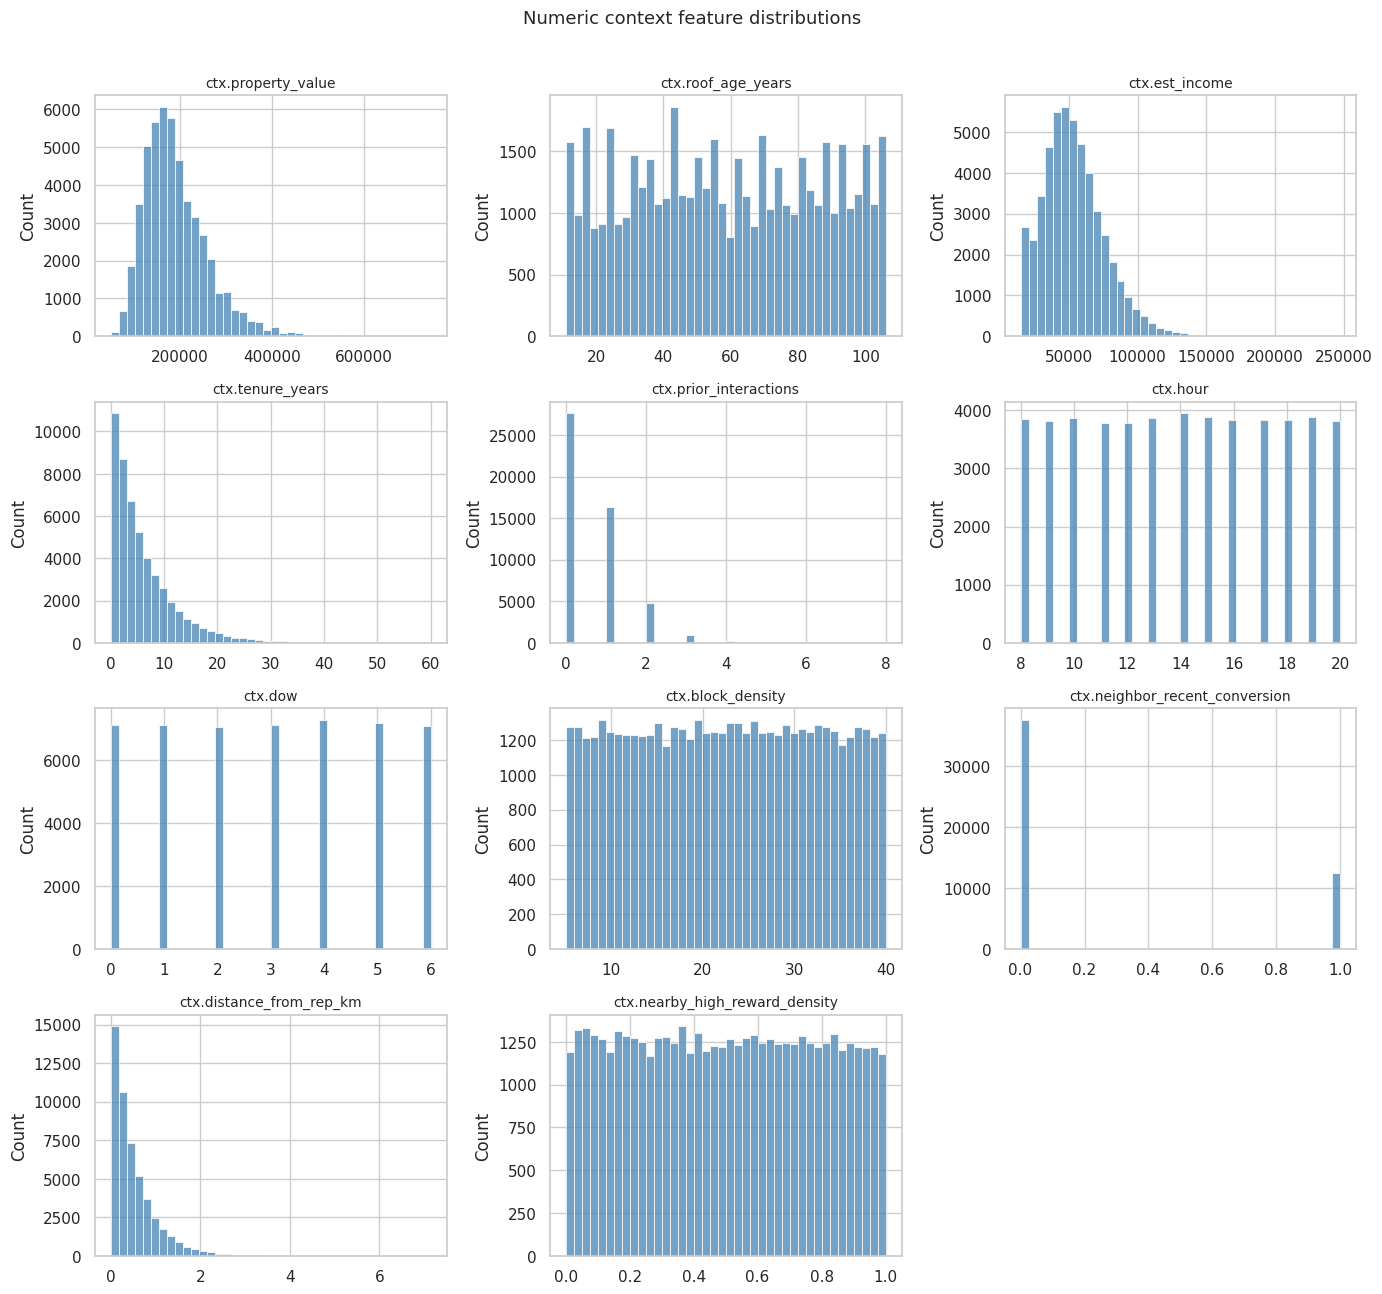

In [8]:
n = len(numeric_ctx)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows))
for ax, col in zip(axes.ravel(), numeric_ctx, strict=False):
    sns.histplot(df[col], bins=40, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
fig.suptitle("Numeric context feature distributions", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

## 4. Univariate distributions — categorical & discrete

`weather`, plus the time fields `hour`/`dow`, and the boolean
`neighbor_recent_conversion`. These tell us about *when* and *under what conditions* decisions
were logged — sampling bias here matters for any downstream policy.

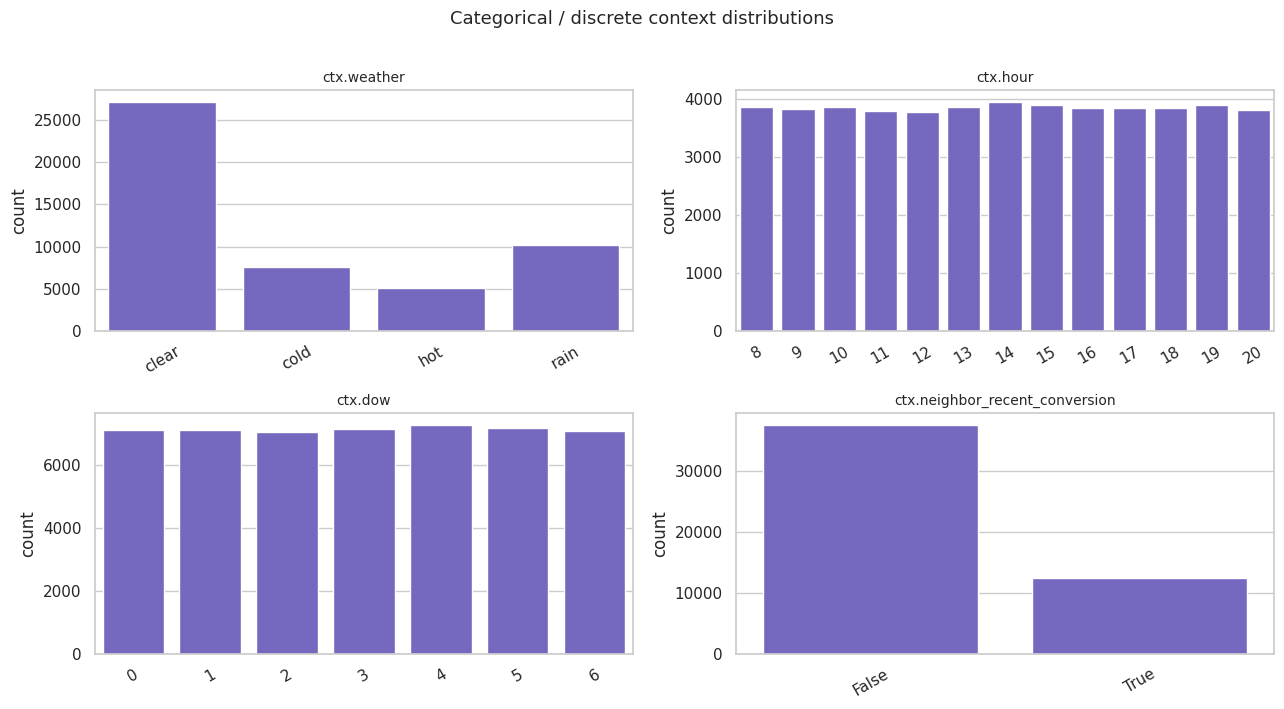

In [9]:
discrete = [
    c for c in ["ctx.weather", "ctx.hour", "ctx.dow", "ctx.neighbor_recent_conversion"] if c in df
]
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, col in zip(axes.ravel(), discrete, strict=False):
    order = sorted(df[col].dropna().unique().tolist())
    sns.countplot(x=df[col], order=order, ax=ax, color="slateblue")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Categorical / discrete context distributions", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

## 5. Correlation structure among numeric features

A correlation heatmap surfaces redundancy (near-duplicate columns) and the broad structure of
the feature space. We include the numeric response columns (`reward`, `propensity`) here too —
*as observers*, to see whether any context feature has an obvious linear association with the
signals. (Most real signal will be non-linear, so weak correlations here don't mean a feature
is useless.)

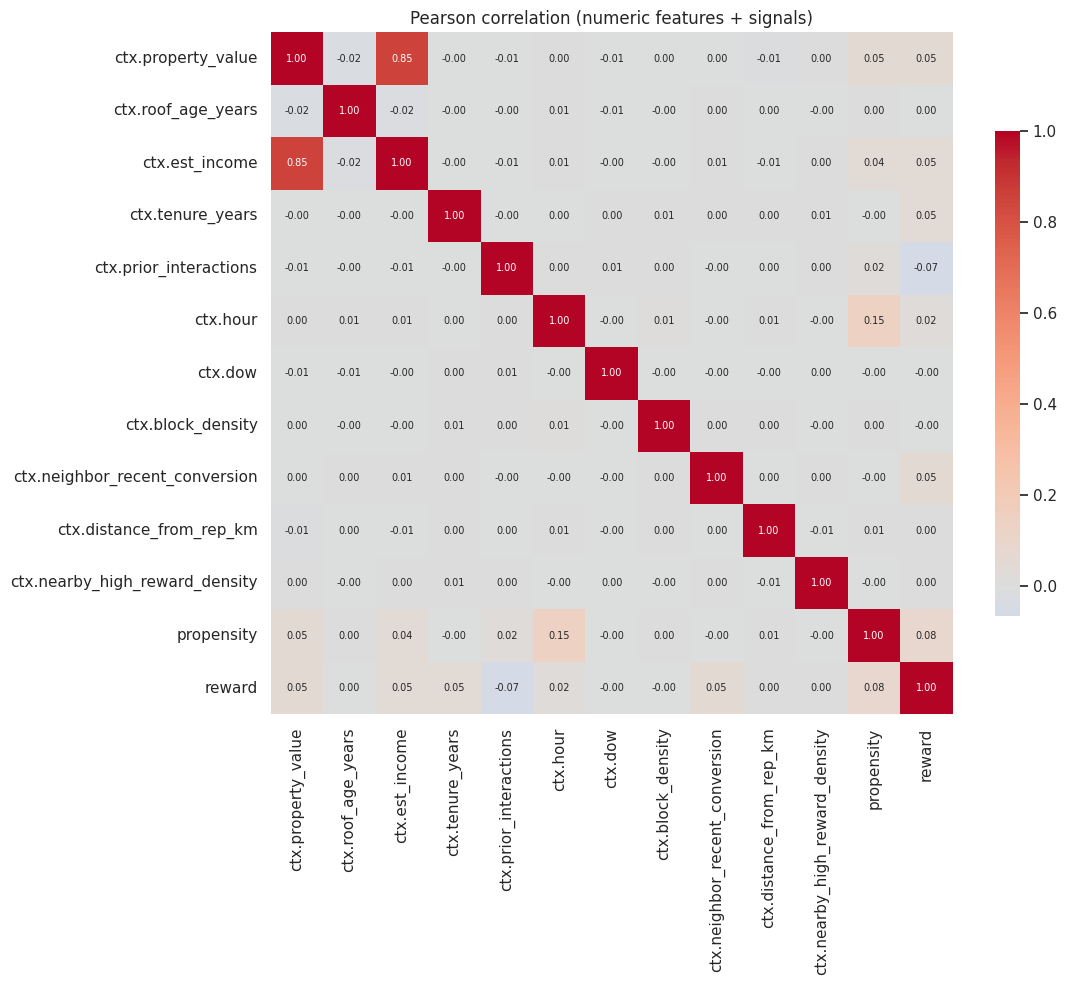

In [10]:
corr_cols = numeric_ctx + ["propensity", "reward"]
corr = df[corr_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.7},
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_title("Pearson correlation (numeric features + signals)", fontsize=12)
plt.show()

In [11]:
# Strongest |correlations| with the observed reward signal.
reward_corr = corr["reward"].drop("reward").sort_values(key=np.abs, ascending=False)
reward_corr.round(3).to_frame("corr_with_reward")

,corr_with_reward
propensity,0.081
ctx.prior_interactions,-0.065
ctx.property_value,0.050
ctx.neighbor_recent_conversion,0.050
ctx.tenure_years,0.045
ctx.est_income,0.045
ctx.hour,0.024
ctx.nearby_high_reward_density,0.003
ctx.distance_from_rep_km,0.002
ctx.dow,-0.002


## 6. The action column — what did the logging policy do?

`action` is categorical. Its frequency tells us how the behavior policy allocated effort, and
combined with `propensity` it reveals how *exploratory* the logging was. Strong imbalance
means some actions are thinly observed — a caveat for any per-action estimate.

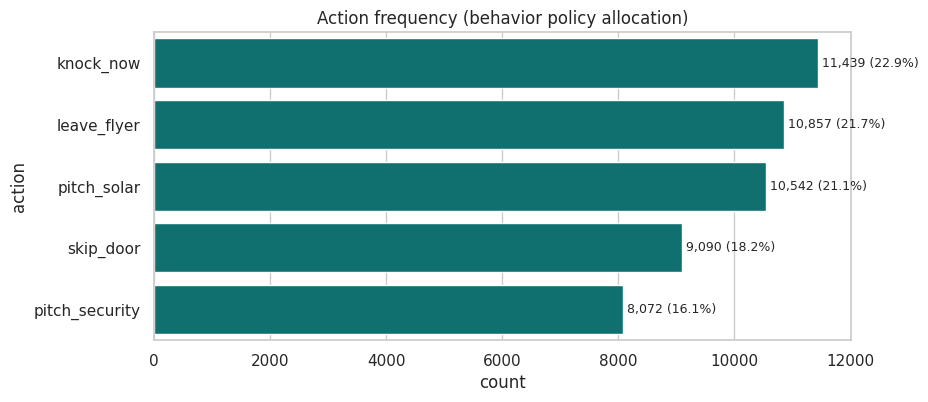

In [12]:
action_counts = df["action"].value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=action_counts.values, y=action_counts.index, color="teal", ax=ax)
ax.set_title("Action frequency (behavior policy allocation)")
ax.set_xlabel("count")
for i, v in enumerate(action_counts.values):
    ax.text(v, i, f" {v:,} ({v / len(df):.1%})", va="center", fontsize=9)
plt.show()

## 7. Propensity — the logging fingerprint

Propensity is the probability the behavior policy assigned to the action it actually took. Its
distribution tells us two things crucial for *off-policy* analysis later:

1. **Overlap / support**: the minimum propensity bounds the worst-case importance weight
   ($1/p$). Very small values would make off-policy estimates high-variance.
2. **Exploration vs. exploitation**: a spike near 1.0 means the policy was often near-greedy; a
   spread toward smaller values means genuine exploration.

min=0.0871  p1=0.1153  median=0.1935  max=0.4434
max importance weight 1/p_min = 11.5


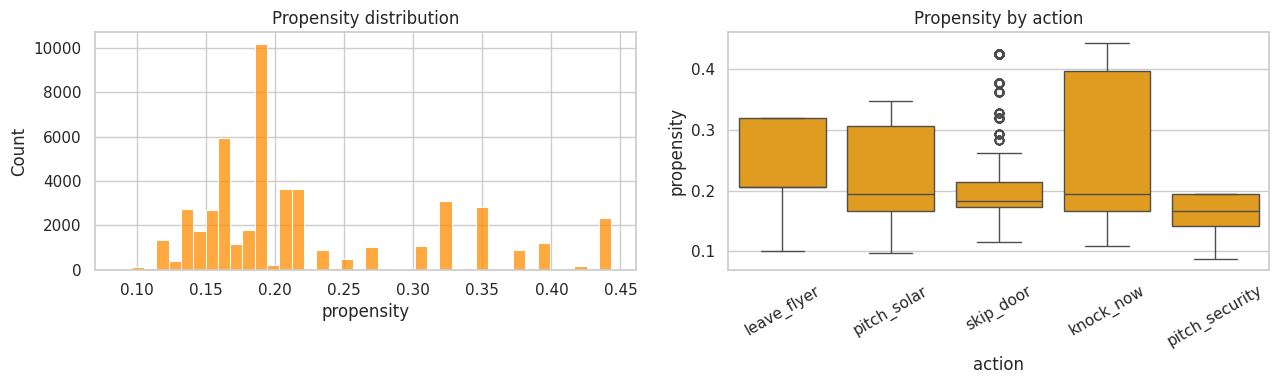

In [13]:
p = df["propensity"]
print(f"min={p.min():.4f}  p1={p.quantile(0.01):.4f}  median={p.median():.4f}  max={p.max():.4f}")
print(f"max importance weight 1/p_min = {1 / p.min():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(p, bins=40, ax=axes[0], color="darkorange")
axes[0].set_title("Propensity distribution")
sns.boxplot(x=df["action"], y=p, ax=axes[1], color="orange")
axes[1].set_title("Propensity by action")
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

## 8. The response signals — reward & outcome

Now the columns that only exist *after* acting. `outcome` is a categorical event; `reward`
looks like a scalar utility. Let's see the marginal reward distribution and how `outcome`
maps onto reward values (often outcomes are a discrete ladder that the reward encodes).

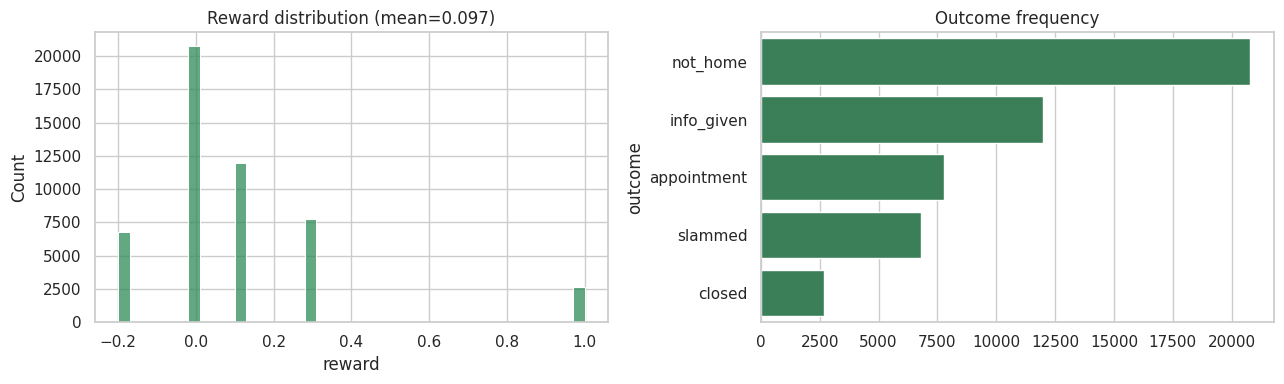

,count,mean,min,max
outcome,,,,
appointment,7781,0.3,0.3,0.3
closed,2666,1.0,1.0,1.0
info_given,11988,0.1,0.1,0.1
not_home,20759,0.0,0.0,0.0
slammed,6806,-0.2,-0.2,-0.2


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["reward"], bins=40, ax=axes[0], color="seagreen")
axes[0].set_title(f"Reward distribution (mean={df['reward'].mean():.3f})")
oc = df["outcome"].value_counts()
sns.barplot(x=oc.values, y=oc.index, color="seagreen", ax=axes[1])
axes[1].set_title("Outcome frequency")
fig.tight_layout()
plt.show()

# Does each outcome correspond to a fixed reward? (discrete reward ladder check)
df.groupby("outcome")["reward"].agg(["count", "mean", "min", "max"]).round(3)

## 9. Conditional view — reward given the action

The single most decision-relevant cut: **how does reward vary by action?** This is the naive
(on-policy) value of each action *as logged*. It is biased — actions were not assigned at
random, so context confounds these averages — but it frames the central question: *which action
should we take in a given context?*

,count,mean,std,se
action,,,,
pitch_solar,10542,0.1437,0.3032,0.0030
knock_now,11439,0.1187,0.2870,0.0027
pitch_security,8072,0.1165,0.2879,0.0032
leave_flyer,10857,0.0944,0.2337,0.0022
skip_door,9090,0.0000,0.0000,0.0000


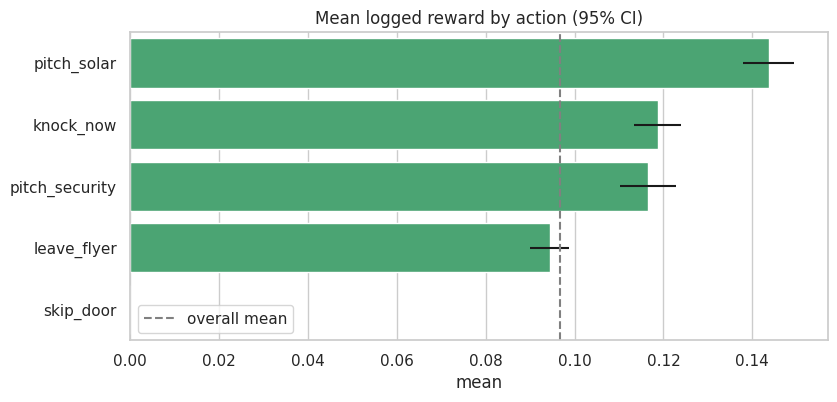

In [15]:
reward_by_action = (
    df.groupby("action")["reward"]
    .agg(["count", "mean", "std"])
    .sort_values("mean", ascending=False)
)
reward_by_action["se"] = reward_by_action["std"] / np.sqrt(reward_by_action["count"])
display(reward_by_action.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
order = reward_by_action.index.tolist()
sns.barplot(
    x=reward_by_action["mean"],
    y=order,
    xerr=1.96 * reward_by_action["se"],
    color="mediumseagreen",
    ax=ax,
)
ax.axvline(df["reward"].mean(), ls="--", color="gray", label="overall mean")
ax.set_title("Mean logged reward by action (95% CI)")
ax.legend()
plt.show()

### Confounding check — is the action–reward gap just context?

Because the logging policy chose actions based on context, a higher average reward for an
action might reflect *which doors it was used on*, not the action's intrinsic effect. A quick
way to sense this: see whether actions differ in the context they were applied to. If they do,
naive per-action means are confounded and we'll need a model that conditions on context.

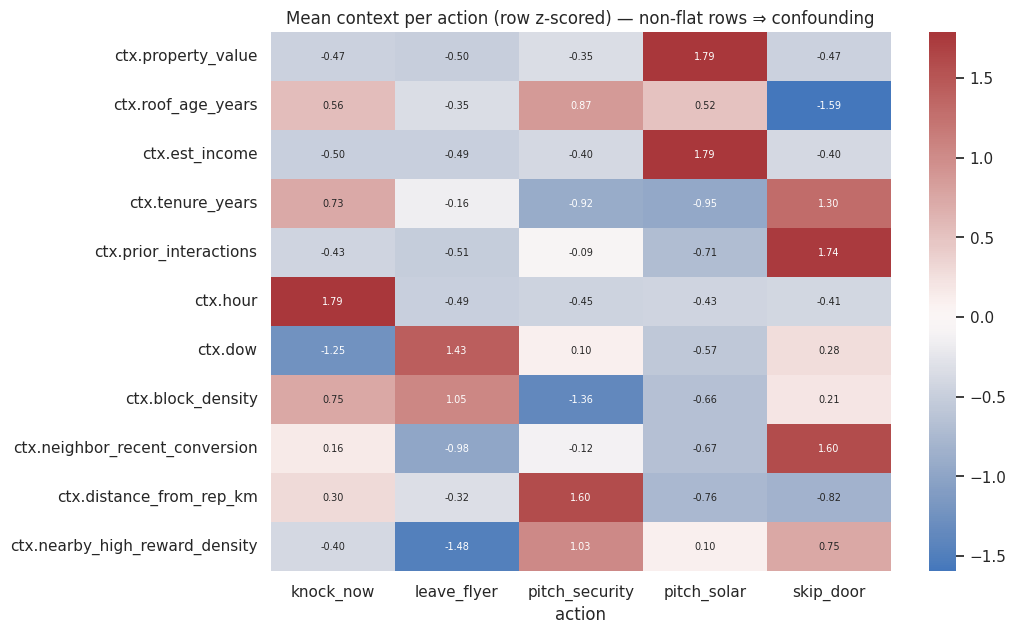

In [16]:
context_by_action = df.groupby("action")[numeric_ctx].mean().T
# z-score each row so columns are comparable across very different scales.
z = context_by_action.sub(context_by_action.mean(axis=1), axis=0).div(
    context_by_action.std(axis=1).replace(0, np.nan), axis=0
)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(z, annot=True, fmt=".2f", cmap="vlag", center=0, annot_kws={"size": 7}, ax=ax)
ax.set_title("Mean context per action (row z-scored) — non-flat rows ⇒ confounding")
plt.show()

## 10. A couple of feature → signal relationships

To build intuition for non-linear structure (which correlations miss), bin a few promising
context features and look at the mean reward per bin. Monotone or curved trends here are
exactly what a gradient-boosted reward model would exploit.

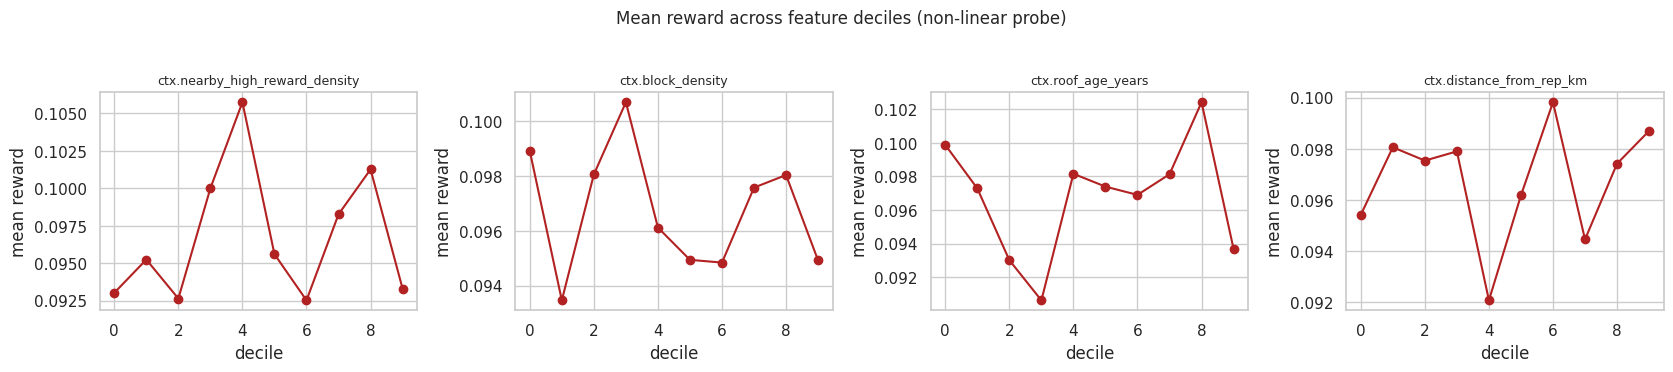

In [17]:
probe = [
    c
    for c in [
        "ctx.nearby_high_reward_density",
        "ctx.block_density",
        "ctx.roof_age_years",
        "ctx.distance_from_rep_km",
    ]
    if c in df
]
fig, axes = plt.subplots(1, len(probe), figsize=(4.2 * len(probe), 3.6))
for ax, col in zip(np.atleast_1d(axes), probe, strict=False):
    binned = pd.qcut(df[col], q=10, duplicates="drop")
    g = df.groupby(binned, observed=True)["reward"].mean()
    ax.plot(range(len(g)), g.values, marker="o", color="firebrick")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("decile")
    ax.set_ylabel("mean reward")
fig.suptitle("Mean reward across feature deciles (non-linear probe)", y=1.03, fontsize=12)
fig.tight_layout()
plt.show()

## 11. Takeaways & where this points

From a target-agnostic look at the logs we can now state with confidence:

- The frame is a **logged contextual-bandit dataset**: `ctx.*` context, a single categorical
  `action`, a logging `propensity`, and post-hoc `reward`/`outcome` signals.
- `outcome` is a small set of events mapping onto a **discrete reward ladder**; `reward` is the
  scalar utility we'd most naturally learn to predict.
- Actions are **imbalanced** and applied to **systematically different contexts**, so raw
  per-action reward means are **confounded** — we need a model `q(context, action)` rather than
  a lookup table.
- Propensities have **bounded support** (no vanishingly small values), which keeps importance
  weights manageable for later off-policy evaluation.
- Several context features show **non-linear** trends against reward, favoring a flexible
  learner (e.g. gradient-boosted trees) with calibration.

Natural next step: build a calibrated **reward model** `q(x, a) = E[r | x, a]` over the `ctx.*`
features plus a one-hot action, validate that it ranks actions sensibly, and check calibration
of its predicted reward against observed reward — which is precisely the modeling task the rest
of the project takes on.